### Missing Values
- Missing Values occurs in datasets when some information is not stored for a variable. There are 3 Mechanisms of Missing Values:

In [ ]:
#(1) Missing Completely at Random (MCAR) imputation method
#  MCAR is a type of missing data mechanism where the probability of missingness is independent of both observed and unobserved data. In other words, the missing values are completely random and do not depend on any other variables in the dataset. the missing values are randomly distributed across the dataset, and there is no systematic pattern to the missingness.
# For example, in a survey about the prevalence of a certian disease, if some participants randomly forget to answer a question about their smoking habits, the missing data would be considered MCAR. The missingness is not related to any other variables in the dataset, such as age

In [ ]:
#(2) Missing at Random (MAR) imputation method
#  MAR is a type of missing data mechanism where the probability of missingness is related to observed data but not to unobserved data. In other words, the missing values are not completely random, but they can be explained by other variables in the dataset. The missingness is systematic and can be predicted based on the observed data.
# For example, in a survey about the prevalence of a certain disease, if older participants are more likely to forget to answer a question about their smoking habits, the missing data would be considered MAR. The missingness is related to age, which is an observed variable in the dataset, but it is not related to unobserved variables such as the participants' health status.
# Mens are  more likely to not disclose thier salary information in a survey, the missing data would be considered MAR. The missingness is related to gender, which is an observed variable in the dataset, but it is not related to unobserved variables such as the participants' financial status.


In [ ]:
# Missing data not at random (MNAR) imputation method
#  MNAR is a type of missing data mechanism where the probability of missingness is related to unobserved data. In other words, the missing values are not random and cannot be explained by other variables in the dataset. The missingness is systematic and is related to the unobserved data itself.
# For example, Mens who are not satisfied with their salary are more likely to not disclose thier salary information in a survey, the missing data would be considered MNAR. The missingness is related to the unobserved variable of salary satisfaction, which is not observed in the dataset, and it cannot be explained by any other observed variables.

In [2]:
import seaborn as sns
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [4]:
# Delete the rows or  data points to handle the missing values
df.shape

(891, 15)

In [5]:
df.dropna().shape # We are losing a lot of data points if we delete the rows with missing values. Hence, we should not use this method to handle the missing values in this dataset.

(182, 15)

In [6]:
# Delete column wise to handle the missing values
df.dropna(axis=1).shape # We are losing a lot of columns if we delete the columns with missing values. Hence, we should not use this method to handle the missing values in this dataset.

(891, 11)

### Imputation Missing values
(1) Mean value imputation method to handle the missing values

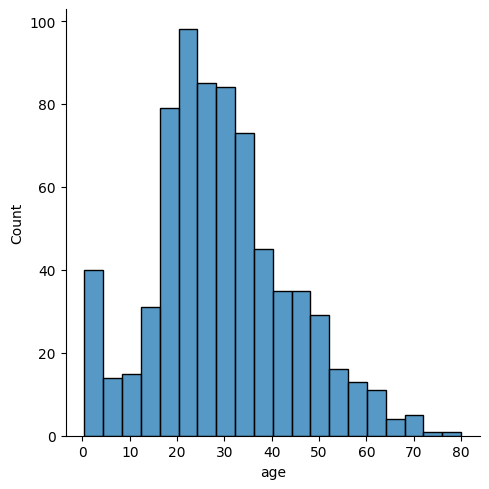

In [7]:
sns.displot(df['age'])

In [8]:
df['age_mean'] = df['age'].fillna(df['age'].mean())


In [9]:
df[['age_mean','age']]

,age_mean,age
0,22.000000,22.0
1,38.000000,38.0
2,26.000000,26.0
3,35.000000,35.0
4,35.000000,35.0
...,...,...
886,27.000000,27.0
887,19.000000,19.0
888,29.699118,NaN
889,26.000000,26.0


- Mean imputation works well when we have normally distributed data 

(2) Median Value imputation : If we have outliers in the datasets 

In [10]:
df['age_median'] = df['age'].fillna(df['age'].median())


In [11]:
df[['age_median','age_mean','age']]

,age_median,age_mean,age
0,22.0,22.000000,22.0
1,38.0,38.000000,38.0
2,26.0,26.000000,26.0
3,35.0,35.000000,35.0
4,35.0,35.000000,35.0
...,...,...,...
886,27.0,27.000000,27.0
887,19.0,19.000000,19.0
888,28.0,29.699118,NaN
889,26.0,26.000000,26.0


(3) Mode Imputation Technqiue-- categorical values

In [12]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [13]:
df['embarked'].unique()


array(['S', 'C', 'Q', nan], dtype=object)

In [14]:
df['embarked'].notna() #If there is Nan value give it false rest all True

0      True
1      True
2      True
3      True
4      True
       ... 
886    True
887    True
888    True
889    True
890    True
Name: embarked, Length: 891, dtype: bool

In [ ]:
df[df['embarked'].notna()] # Wherever there is Nan value in embark coloumn it will get skipped

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,22.000000,22.0
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,38.000000,38.0
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,26.000000,26.0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,35.000000,35.0
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,35.000000,35.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,27.000000,27.0
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,19.000000,19.0
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,29.699118,28.0
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,26.000000,26.0


In [23]:
mode_value = df[df['embarked'].notna()]['embarked'].mode()[0]

In [25]:
df['embarked_mode']=df['embarked'].fillna(mode_value)

In [ ]:
df[['embarked_mode','embarked']] # All the Nan value in embarked coloumn are replaced by embarked_mode

,embarked_mode,embarked
0,S,S
1,C,C
2,S,S
3,S,S
4,S,S
...,...,...
886,S,S
887,S,S
888,S,S
889,C,C
